# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [Henry Fong]

**Date:** [09/09/2026]

![Q1](data/Q1.jpg)
![Q2](data/Q2.jpg)
![Q3](data/Q3.jpg)
#4 No it is not always true for example if we have g(x) = x^2 and we have values such as 1,2,3 m(g(x)) is 4.67 while g(m(x)) is 4 and since they are both not equal to one another they are not always true

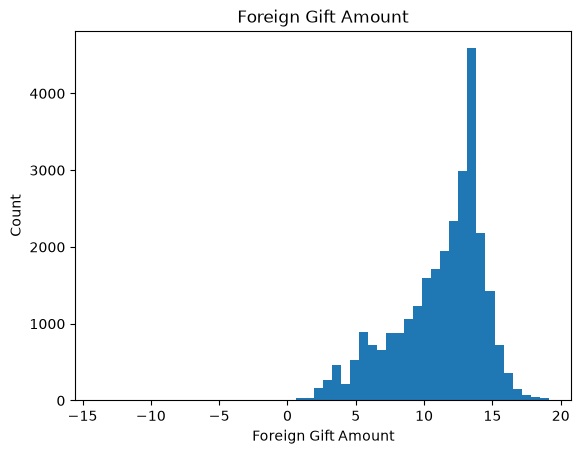

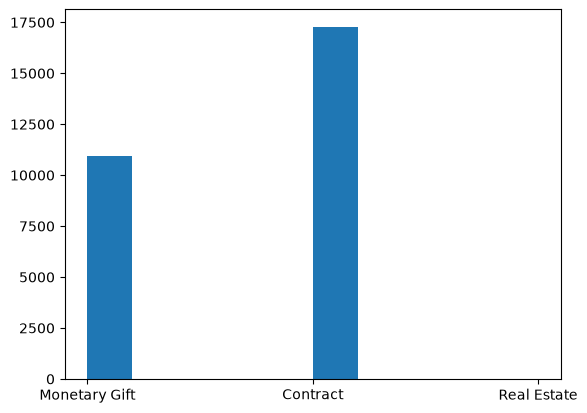

proportion: 
 Contract: 61% 
 Real Estate: 0% 
 Monetary Gift Estate: 39%


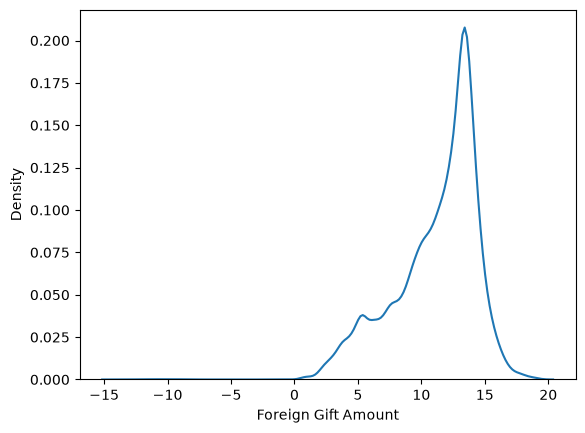

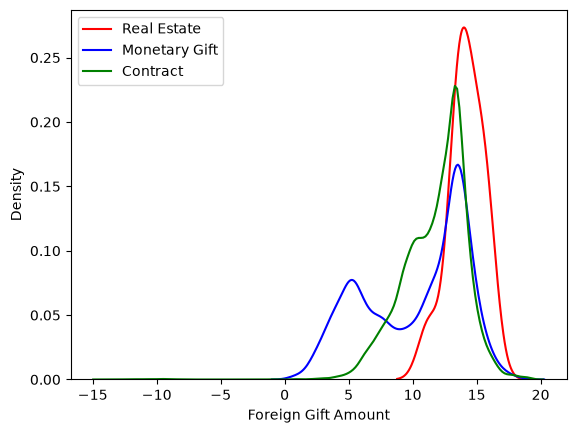

Top 15 countries in terms of number of giftsCountry of Giftor
ENGLAND            47713393
CHINA              33468243
SWITZERLAND        29044550
CANADA             28437385
JAPAN              22888812
SAUDI ARABIA       20193035
GERMANY            18986157
FRANCE             17333036
QATAR              14133760
HONG KONG          14000547
THE NETHERLANDS     9854070
SOUTH KOREA         7916635
INDIA               7209712
SINGAPORE           6067534
ITALY               5808591
Name: ID, dtype: int64 
 Top 15 countries in terms of amount givenCountry of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE        

In [40]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv("data/ForeignGifts_edu.csv")

# The vast majority of gift amount 10-15 with a peak around the 14 mark
df["Foreign_Gift_Amount_arcsinh"] = np.arcsinh(df["Foreign Gift Amount"])
df["Foreign_Gift_Amount_arcsinh"].hist(bins=50, grid=False)
plt.title("Foreign Gift Amount")
plt.xlabel("Foreign Gift Amount")
plt.ylabel("Count")
plt.show()

df["Gift Type"].hist(grid=False)
plt.show()
contract_amount = len(df[df["Gift Type"] == "Contract"])
real_estate_amount = len(df[df["Gift Type"] == "Real Estate"])
monetary_gift_amount = len(df[df["Gift Type"] == "Monetary Gift"])
total_contract = contract_amount + real_estate_amount + monetary_gift_amount
print(f"proportion: \n Contract: {round((contract_amount/total_contract) * 100)}% \n Real Estate: {round((real_estate_amount/total_contract) * 100)}% \n Monetary Gift Estate: {round((monetary_gift_amount/total_contract) * 100)}%")

sns.kdeplot(df["Foreign_Gift_Amount_arcsinh"])
plt.xlabel("Foreign Gift Amount")
plt.show()

"""
Real Estate has the largest peak that is also the largest gift amount of all gift type
Contract is the next largest gift amount and monetary gift has two noticable peaks compare to one for the others
"""

sns.kdeplot(df.loc[(df["Gift Type"]=="Real Estate"),
            "Foreign_Gift_Amount_arcsinh"], color="red", label='Real Estate')
sns.kdeplot(df.loc[(df["Gift Type"]=='Monetary Gift'), 
            "Foreign_Gift_Amount_arcsinh"], color="blue", label='Monetary Gift')
sns.kdeplot(df.loc[(df["Gift Type"]=='Contract'), 
            "Foreign_Gift_Amount_arcsinh"], color="green", label='Contract')
plt.xlabel("Foreign Gift Amount")
plt.legend()
plt.show()

print(f"Top 15 countries in terms of number of gifts{df.groupby("Country of Giftor")["ID"].sum().sort_values(ascending=False).head(15)} \n Top 15 countries in terms of amount given{df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(15)}")
print(f"Giftor that provided the most money: {df.groupby("Giftor Name")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(1)}")


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [bceb77b]
- **AI tool and model used:** [Google Gemini]

### *Prompts used

1. [Check these images and this explaination did I do it correctly?]
2. [Check these code and tell me if there is any errors that I made?]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Your work is overall very solid, but there are a few notable notation errors and calculation details to fix in **Question 1**, **Question 3**, and **Question 4**.

---

### **Question 1: Partial Error in Image**

Your general flow is right, but you wrote **$m(X)$** on the left side throughout the steps instead of **$m(a + bX)$**, and missed the variable $X_i$ in line 2:

* **Line 2 correction:** It should start with $m(a + bX) = \frac{1}{N} \sum_{i=1}^N (a + bX_i)$.
* **Line 3 correction:** Split the summation into $\frac{1}{N}\left(\sum_{i=1}^N a + \sum_{i=1}^N bX_i\right)$.
* **Line 4–6:** Since $\sum_{i=1}^N a = N \cdot a$, you get $\frac{1}{N}(N \cdot a) + b \left(\frac{1}{N} \sum_{i=1}^N X_i\right) = a + b \cdot m(X)$.

---

### **Question 2: Correct!**

Your handwritten proof for $\text{cov}(X, a + bY) = b \cdot \text{cov}(X, Y)$ is completely correct step-by-step.

---

### **Question 3: Minor Gap**

Your algebraic steps showing $\text{cov}(a+bX, a+bX) = b^2 \cdot s^2$ are correct, but you forgot to explicitly answer the second part of the question: **"and in particular that $\text{cov}(X,X) = s^2$"**.

To complete the proof, set $a = 0$ and $b = 1$:


$$\text{cov}(X,X) = \text{cov}(0 + 1X, 0 + 1X) = 1^2 \cdot s^2 = s^2 = \frac{1}{N}\sum_{i=1}^N (X_i - m(X))^2$$

---

### **Question 4: Counterexample Calculation Fix**

Your conclusion that the statement is **False** is correct, but your arithmetic for the counterexample is slightly off:

* **Data set:** $X = \{1, 2, 3\}$ with transformation $g(x) = x^2$
* **$m(X)$ calculation:** $m(X) = \frac{1+2+3}{3} = 2$
* **$g(m(X))$:** $g(2) = 2^2 = 4$
* **$m(g(X))$:** First compute $g(X) = \{1^2, 2^2, 3^2\} = \{1, 4, 9\}$.

$$m(g(X)) = \frac{1 + 4 + 9}{3} = \frac{14}{3} \approx 4.67$$



Since $4.67 \neq 4$, the statement $m(g(X)) = g(m(X))$ is **not** always true for non-linear non-decreasing transformations. (Just make sure to show the $\frac{14}{3}$ step clearly in your final write-up so your instructor sees where $4.67$ came from).

2. You have a critical logical error in Question 5, a transformation mismatch in Questions 2 and 4, and potential syntax errors with f-strings.

Errors and Fixes

Q5 Logical Error (Summing IDs instead of counting): You used df.groupby("Country of Giftor")["ID"].sum(). Summing ID numbers adds their numerical values together rather than counting occurrences.

Fix: Use .count() or .size() to tally occurrences (e.g., df.groupby("Country of Giftor")["Foreign Gift Amount"].count()).

Q2 & Q4 Transformation Mismatch: The prompt specifically asks for the log of Foreign Gift Amount in Question 4 (np.log() or np.log1p()), but you used np.arcsinh(). Question 2 also asks for the histogram of Foreign Gift Amount directly before Question 4 introduces the transformation.

F-String Syntax Errors: Reusing double quotes inside double-quoted f-strings (e.g., f"{df.groupby("Country of Giftor")...}") will raise a SyntaxError in Python versions prior to 3.12.

Fix: Use single quotes for column names inside f-strings (e.g., f"{df.groupby('Country of Giftor')...}").

Q3 Inefficiency & Typo: Manually calculating len() for each category is overly verbose and prone to error. You also printed "Monetary Gift Estate" instead of "Monetary Gift".

Fix: Use df["Gift Type"].value_counts(normalize=True) * 100 to quickly calculate accurate proportions.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / **reject** | While Google Gemini response is correct it mentioned small tiny issues that I made instead of large issues that would have caused the question to be wrong |
| 2 | **Accept** / modify / reject | I used some of the wrong functions for some of the questions but I also used some of the functions incorrectly which could mean my answers are false |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [41]:
# Your Phase 2 solution to the problem goes here.


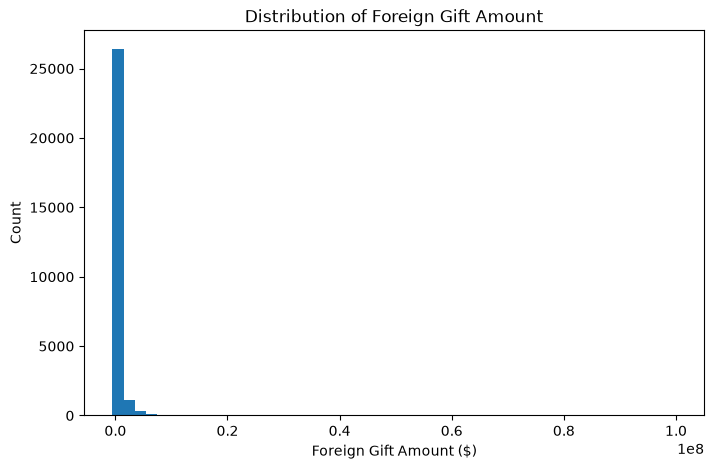

Gift Type Proportions (%):
Gift Type
Contract         61.21
Monetary Gift    38.75
Real Estate       0.04
Name: proportion, dtype: float64


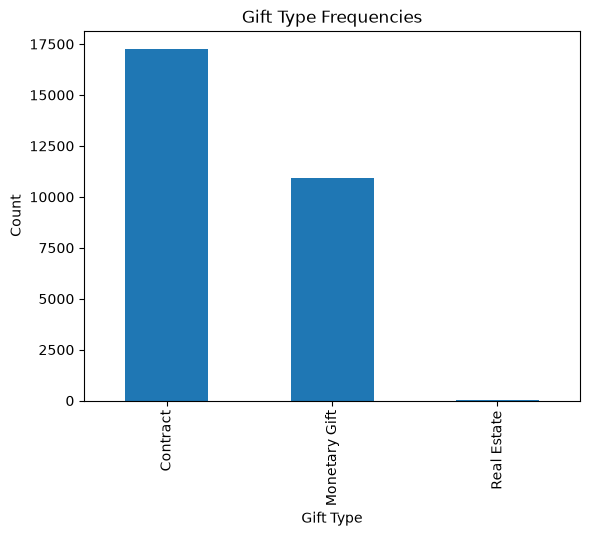

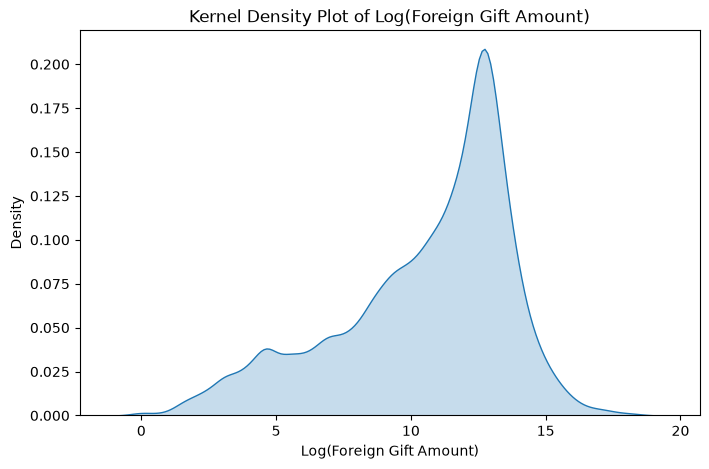

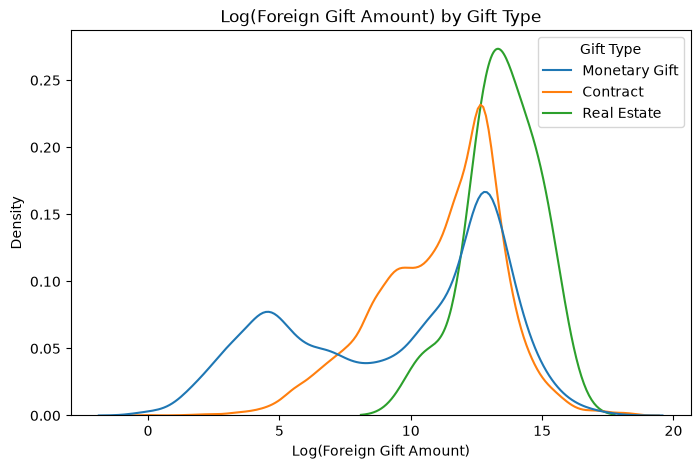

Top 15 countries by number of gifts:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64

Top 15 countries by total amount given:
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv("data/ForeignGifts_edu.csv")

# 2. Histogram of Foreign Gift Amount (raw distribution)
plt.figure(figsize=(8, 5))
df["Foreign Gift Amount"].hist(bins=50, grid=False)
plt.title("Distribution of Foreign Gift Amount")
plt.xlabel("Foreign Gift Amount ($)")
plt.ylabel("Count")
plt.show()

# 3. Gift Type Proportions
print("Gift Type Proportions (%):")
proportions = df["Gift Type"].value_counts(normalize=True) * 100
print(proportions.round(2))

# Plot Gift Type distribution
df["Gift Type"].value_counts().plot(kind="bar")
plt.title("Gift Type Frequencies")
plt.xlabel("Gift Type")
plt.ylabel("Count")
plt.show()

# 4. Kernel Density Plots (Log Transformation)
# Using np.log1p to safely handle zero values if present: log(1 + x)
valid_gifts = df["Foreign Gift Amount"][df["Foreign Gift Amount"] > 0]
df["log_gift_amount"] = np.log(valid_gifts)

# Overall log density plot
plt.figure(figsize=(8, 5))
sns.kdeplot(df["log_gift_amount"], fill=True)
plt.title("Kernel Density Plot of Log(Foreign Gift Amount)")
plt.xlabel("Log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.show()

# Conditional log density plot by Gift Type
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=df,
    x="log_gift_amount",
    hue="Gift Type",
    common_norm=False,
)
plt.title("Log(Foreign Gift Amount) by Gift Type")
plt.xlabel("Log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.show()

# 5. Top 15 countries by number of gifts and amount given
top_countries_count = (
    df.groupby("Country of Giftor")["Foreign Gift Amount"]
    .count()
    .sort_values(ascending=False)
    .head(15)
)

top_countries_amount = (
    df.groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

print(
    f"Top 15 countries by number of gifts:\n{top_countries_count}\n"
)
print(
    f"Top 15 countries by total amount given:\n{top_countries_amount}\n"
)

# 6. Top giftor by total money provided
top_giftor = (
    df.groupby("Giftor Name")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

print(f"Giftor that provided the most money in total:\n{top_giftor}")

### *Reflection on AI assistance
In your own words without generative AI.

The main improvements that AI made was helping to make sure I used the correct functions and made sure my results are correct. For example, in finding the country that donated the most I used sum which gave me an incorrect value and I was supposed to use count. It also told me some of my results were wrong such as I was supposed to use log however I did not use log which made one of the graphs I did get to be incorrect. AI did make some mistakes such as using a function that gave me an error however that was due to the fact it did not know what data was inside of the dataset however looking at the error it was able to fix the issue. The final solution was verified by checking the data and making sure it was not wrong by a wide margin.